# Prática com Redes Neurais em Grafos (Graph Neural Networks - GNNs)

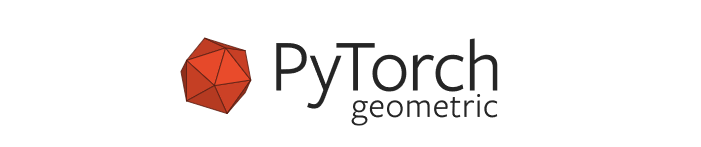

## Contextualização histórica e motivação

Redes Neurais em Grafos (GNNs) surgiram da necessidade de aplicar o poder do Deep Learning a dados estruturados em forma de grafos. Diferente de imagens (que podem ser vistas como grades regulares de pixels) ou textos (sequências unidimensionais), dados do mundo real como redes sociais, moléculas, mapas de trânsito e grafos de conhecimento possuem topologias complexas e irregulares.

Como visto na base teórica do curso, grafos conectam dados explicitamente e são ótimos para navegação, causalidade, e para modelar entidades e relações (ex: redes sociais, detecção de fraude). Historicamente, os primeiros modelos formais de GNN foram introduzidos por Gori et al. (2005) e Scarselli et al. (2008), mas a área decolou de fato com o surgimento das *Graph Convolutional Networks* (GCN) por Kipf & Welling em 2016.

## Intuição e visualização

A intuição principal por trás das GNNs é o mecanismo de **"Message Passing" (Passagem de Mensagens)**. Imagine que cada nó (vértice) em um grafo possui um estado inicial (suas *features* ou atributos). A cada camada da GNN, um nó "escuta" as mensagens de todos os seus vizinhos através das arestas, agrega essas informações e as combina com seu próprio estado atual para gerar uma nova representação atualizada.

* Visualmente, em uma molécula (que será nosso exemplo ao longo do notebook), os átomos são os **nós** e as ligações químicas são as **arestas**.
* Uma camada da GNN faz com que um átomo de carbono, por exemplo, capture a informação de que está ligado a um átomo de oxigênio. Após duas camadas, ele também absorve a informação dos átomos ligados ao oxigênio (vizinhos a 2 saltos de distância), expandindo seu "campo de visão" na estrutura do grafo.

## Teoria formal e análise

Formalmente, um grafo é definido como $G = (V, E)$, onde $V$ é o conjunto de vértices (nós) e $E$ é o conjunto de arestas (conexões). Em uma *Graph Convolutional Network* (GCN), a atualização da matriz de características dos nós $H^{(l)}$ na camada $l$ é frequentemente dada por:

$$H^{(l+1)} = \sigma \left( \tilde{D}^{-\frac{1}{2}} \tilde{A} \tilde{D}^{-\frac{1}{2}} H^{(l)} W^{(l)} \right)$$

Onde:
- $\tilde{A} = A + I$ é a matriz de adjacência do grafo com auto-conexões adicionadas (garantindo que o nó considere suas próprias *features* durante a atualização).
- $\tilde{D}$ é a matriz de grau correspondente a $\tilde{A}$, usada para normalizar as mensagens de acordo com a quantidade de vizinhos.
- $W^{(l)}$ é a matriz de pesos treináveis da camada $l$.
- $\sigma$ é uma função de ativação não-linear (como ReLU ou Tanh).

Essa operação equivale a uma média ponderada das *features* vizinhas seguida de uma transformação linear e uma ativação não linear. Ao final de várias camadas de *Message Passing*, podemos agregar todas as *features* dos nós em um vetor global (com um Global Pooling) e fazer uma predição em **nível de grafo** (ex: prever a solubilidade de toda a molécula de uma só vez, o que você verá na prática abaixo).

## Instalando Pytorch Geometric e RDKit

- Pytorch Geometric => Construir a Rede Neural em Grafos
- RDKit => Lidar com Dados Moleculares

_Este notebook está atualizado para Python 3.12.3. Utilize o ambiente virtual ativo e instale os pacotes com `%pip` para que sejam adicionados ao mesmo kernel._

In [1]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Enforce pytorch version 1.6.0
import torch

# Check pytorch version and make sure you use a GPU Kernel
!python -c "import torch; print(torch.__version__)"
!python -c "import torch; print(torch.version.cuda)"
!python --version

2.11.0+cu130
13.0
Python 3.12.3


> Certifique-se de ter clicado em "RESTART RUNTIME" (Reiniciar Ambiente de Execução) acima, caso a versão do torch estivesse diferente!

In [3]:
# Install packages in the active notebook kernel (Python 3.12.3)
import sys
from logging import INFO, StreamHandler, getLogger

logger = getLogger(__name__)
if not logger.handlers:
    logger.addHandler(StreamHandler())
logger.setLevel(INFO)

logger.info("Python: %s", sys.version.split()[0])
logger.info("Executable: %s", sys.executable)

%pip install -U pip setuptools wheel
%pip install rdkit
%pip install torch_geometric

Python: 3.12.3
Executable: /home/dmasc/.pyenv/versions/3.12.3/bin/python3


  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 81.0.0
    Uninstalling setuptools-81.0.0:
      Successfully uninstalled setuptools-81.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.11.0 requires setuptools<82, but you have setuptools 82.0.1 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Validate the core packages after installation.
import sys

import torch

print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.version.cuda}")

%pip show rdkit torch_geometric

Python: 3.12.3
PyTorch: 2.11.0+cu130
CUDA: 13.0


Name: rdkit
Version: 2026.3.1
Summary: A collection of chemoinformatics and machine-learning software written in C++ and Python
Home-page: https://github.com/kuelumbus/rdkit-pypi
Author: Christopher Kuenneth
Author-email: chris@kuenneth.dev
License: BSD-3-Clause
Location: /home/dmasc/.pyenv/versions/3.12.3/lib/python3.12/site-packages
Requires: numpy, Pillow
Required-by: 
---
Name: torch-geometric
Version: 2.7.0
Summary: Graph Neural Network Library for PyTorch
Home-page: https://pyg.org
Author: 
Author-email: Matthias Fey <matthias@pyg.org>
License-Expression: MIT
Location: /home/dmasc/.pyenv/versions/3.12.3/lib/python3.12/site-packages
Requires: aiohttp, fsspec, jinja2, numpy, psutil, pyparsing, requests, tqdm, xxhash
Required-by: 
Note: you may need to restart the kernel to use updated packages.


## Informações de contexto sobre o Dataset

A seguir, usaremos um dataset fornecido na coleção de datasets do PyTorch Geometric ([Aqui você encontra todos os datasets](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html)). O Dataset vem da coleção MoleculeNet, que pode ser encontrada [aqui](http://moleculenet.ai/datasets-1).

>"ESOL é um pequeno dataset composto por dados de solubilidade em água de 1128 compostos. O dataset foi usado para treinar modelos que estimam a solubilidade diretamente a partir das estruturas químicas (codificadas em strings SMILES). Note que essas estruturas não incluem coordenadas 3D, uma vez que a solubilidade é uma propriedade de uma molécula e não de seus conformeros particulares."

**>>> Tarefa de Machine Learning: Como diferentes moléculas se dissolvem na água?**

### Representação SMILES e notas importantes

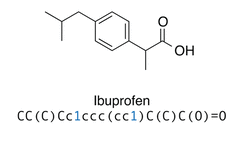

 Source: https://medium.com/@sunitachoudhary103/generating-molecules-using-a-char-rnn-in-pytorch-16885fd9394b

- Usar puramente a string SMILES como entrada não é o ideal para redes neurais densas na tentativa de captar propriedades espaciais de física-química.
- Tais abordagens dariam menos importância à estrutura real não-euclidiana da molécula e mais no formato gramatical da string, o que pode variar dependendo da notação ou isomerismo.
- Uma mesma molécula real e única pode gerar diferentes representações textuais na notação SMILES!
- Modelagens de Grafos Químicos (Chemical Graphs), porém, resistem a permutações de dados ou de ângulos de câmera: a matriz de adjacência conectando os mesmos átomos é o que importa --> É aí que entram as Graph Neural Networks (GNNs).

 
## Investigando o Dataset

In [5]:
import rdkit
from torch_geometric.datasets import MoleculeNet

# Load the ESOL dataset
data = MoleculeNet(root=".", name="ESOL")
data

/home/dmasc/.pyenv/versions/3.12.3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing...
Done!


ESOL(1128)

Nota: Parece haver uma mudança na classe Dataset e de alguma forma a dimensão alvo (target dim) agora é igual a 734 em vez de 1. Você pode simplesmente ignorar isso neste momento. :)

In [6]:
# Investigating the dataset
print("Dataset type: ", type(data))
print("Dataset features: ", data.num_features)
print("Dataset target: ", data.num_classes)
print("Dataset length: ", data.len)
print("Dataset sample: ", data[0])
print("Sample  nodes: ", data[0].num_nodes)
print("Sample  edges: ", data[0].num_edges)

# edge_index = graph connections
# smiles = molecule with its atoms
# x = node features (32 nodes have each 9 features)
# y = labels (dimension)

Dataset type:  <class 'torch_geometric.datasets.molecule_net.MoleculeNet'>
Dataset features:  9
Dataset target:  734
Dataset length:  <bound method InMemoryDataset.len of ESOL(1128)>
Dataset sample:  Data(x=[32, 9], edge_index=[2, 68], edge_attr=[68, 3], smiles='OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O ', y=[1, 1])
Sample  nodes:  32
Sample  edges:  68


/home/dmasc/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch_geometric/data/in_memory_dataset.py:91: UserWarning: Found floating-point labels while calling `dataset.num_classes`. Returning the number of unique elements. Please make sure that this is expected before proceeding.
  return self._infer_num_classes(self._data.y)


In [7]:
# Investigating the features
# Shape: [num_nodes, num_node_features]
data[0].x

tensor([[8, 0, 2, 5, 1, 0, 4, 0, 0],
        [6, 0, 4, 5, 2, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 0, 0, 4, 0, 1],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 0, 0, 4, 0, 0],
        [6, 0, 4, 5, 2, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 0, 0, 4, 0, 1],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 0, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 0],
        [6, 0, 2, 5, 0, 0, 2, 0, 0],
        [7, 0, 1, 5, 0, 0, 2, 0, 0],
        [6, 0, 3, 5, 0, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 1, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 1, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 1, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
 

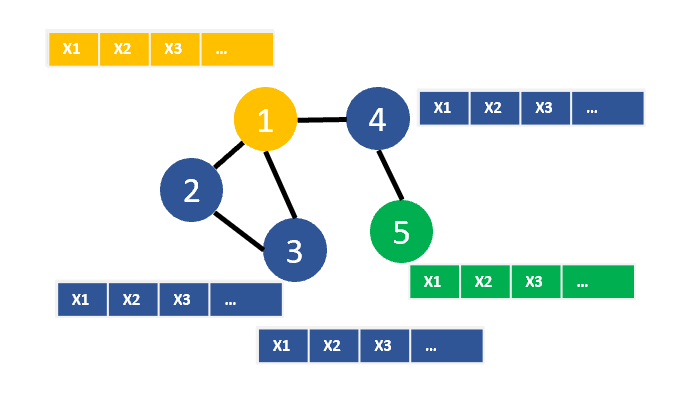

In [8]:
# Investigating the edges in sparse COO format
# Shape [2, num_edges]
data[0].edge_index.t()

tensor([[ 0,  1],
        [ 1,  0],
        [ 1,  2],
        [ 2,  1],
        [ 2,  3],
        [ 2, 30],
        [ 3,  2],
        [ 3,  4],
        [ 4,  3],
        [ 4,  5],
        [ 4, 26],
        [ 5,  4],
        [ 5,  6],
        [ 6,  5],
        [ 6,  7],
        [ 7,  6],
        [ 7,  8],
        [ 7, 24],
        [ 8,  7],
        [ 8,  9],
        [ 9,  8],
        [ 9, 10],
        [ 9, 20],
        [10,  9],
        [10, 11],
        [11, 10],
        [11, 12],
        [11, 14],
        [12, 11],
        [12, 13],
        [13, 12],
        [14, 11],
        [14, 15],
        [14, 19],
        [15, 14],
        [15, 16],
        [16, 15],
        [16, 17],
        [17, 16],
        [17, 18],
        [18, 17],
        [18, 19],
        [19, 14],
        [19, 18],
        [20,  9],
        [20, 21],
        [20, 22],
        [21, 20],
        [22, 20],
        [22, 23],
        [22, 24],
        [23, 22],
        [24,  7],
        [24, 22],
        [24, 25],
        [2

In [9]:
data[0].y

tensor([[-0.7700]])

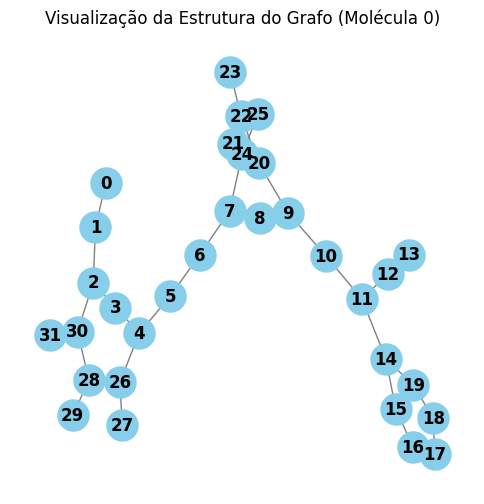

In [10]:
# Célula extra para Visualização do Grafo de uma Molécula
import networkx as nx
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt

# Converte o primeiro grafo do dataset para o formato NetworkX
G = to_networkx(data[0], to_undirected=True)

plt.figure(figsize=(6, 6))
plt.title("Visualização da Estrutura do Grafo (Molécula 0)")
nx.draw(G, with_labels=True, node_color='skyblue', node_size=500, edge_color='gray', font_weight='bold')
plt.show()

A seguir, faremos predições com base no nível do grafo (graph level). Isso significa que temos um rótulo *y* (label) para o grafo inteiro, conforme mostrado na imagem da esquerda abaixo. A imagem da direita representa predições em nível de nó (node-level).

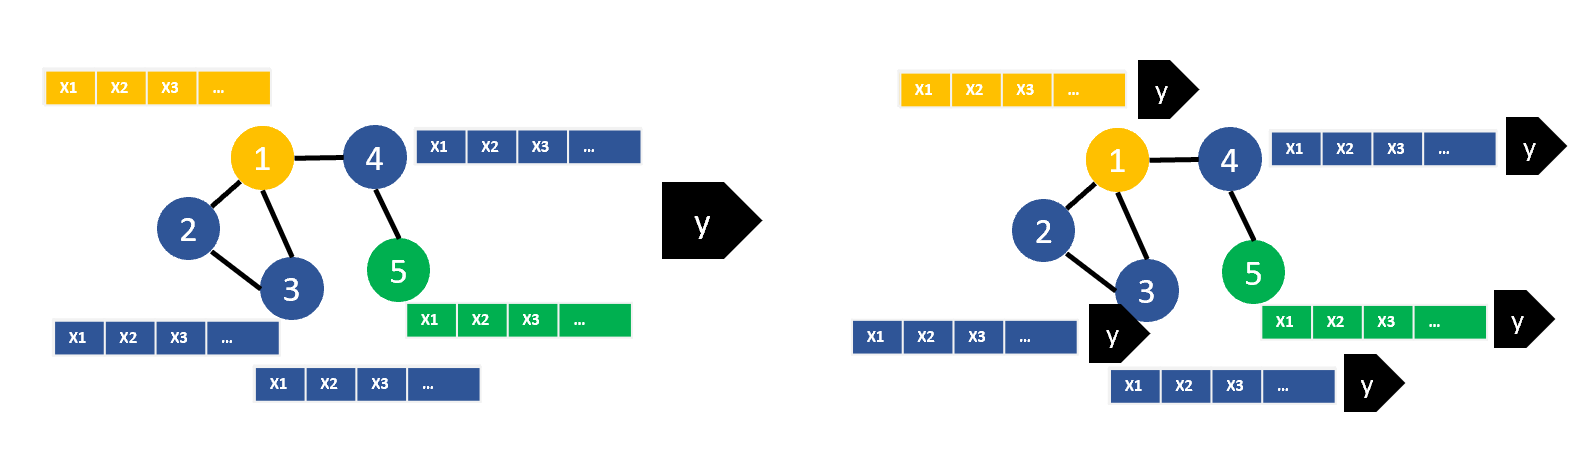

## Convertendo SMILES em moléculas RDKit - Visualizando Moléculas

A seguir queremos ter nossas moléculas SMILES como grafos...

In [11]:
data[0]["smiles"]

'OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O '

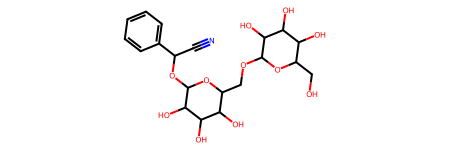

In [ ]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
molecule = Chem.MolFromSmiles(data[0]["smiles"])
molecule

In [13]:
type(molecule)

rdkit.Chem.rdchem.Mol

- Também podemos obter as features a partir desta representação RDKit
- Ela nos diz tudo que precisamos saber: features dos átomos (tipo, ...), arestas, etc.
- **No nosso caso, no entanto, é ainda mais fácil pois já temos as features dos nós disponíveis no dataset que baixamos.**

## Implementando a Rede Neural em Grafos

Construir uma Rede Neural em Grafos funciona da mesma forma que construir uma Rede Neural Convolucional (CNN): simplesmente adicionamos algumas camadas.

A GCN simplesmente estende `torch.nn.Module`.
O `GCNConv` espera:
- `in_channels` = Tamanho das features dos nós de entrada
- `out_channels` = Tamanho do embedding de saída

O `TopKPooling` é responsável por reduzir o número de nós (comprimindo a representação).
O `global_mean_pool` faz a média de todos os nós para criar a representação do grafo inteiro.

In [14]:
import torch
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, TopKPooling, global_mean_pool
from torch_geometric.nn import global_mean_pool as gap, global_max_pool as gmp
embedding_size = 64

class GCN(torch.nn.Module):
    def __init__(self):
        # Init parent
        super(GCN, self).__init__()
        torch.manual_seed(42)

        # GCN layers
        self.initial_conv = GCNConv(data.num_features, embedding_size)
        self.conv1 = GCNConv(embedding_size, embedding_size)
        self.conv2 = GCNConv(embedding_size, embedding_size)
        self.conv3 = GCNConv(embedding_size, embedding_size)

        # Output layer
        self.out = Linear(embedding_size*2, 1)

    def forward(self, x, edge_index, batch_index):
        # First Conv layer
        hidden = self.initial_conv(x, edge_index)
        hidden = F.tanh(hidden)

        # Other Conv layers
        hidden = self.conv1(hidden, edge_index)
        hidden = F.tanh(hidden)
        hidden = self.conv2(hidden, edge_index)
        hidden = F.tanh(hidden)
        hidden = self.conv3(hidden, edge_index)
        hidden = F.tanh(hidden)

        # Global Pooling (stack different aggregations)
        hidden = torch.cat([gmp(hidden, batch_index),
                            gap(hidden, batch_index)], dim=1)

        # Apply a final (linear) classifier.
        out = self.out(hidden)

        return out, hidden

model = GCN()
print(model)
print("Number of parameters: ", sum(p.numel() for p in model.parameters()))

GCN(
  (initial_conv): GCNConv(9, 64)
  (conv1): GCNConv(64, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (out): Linear(in_features=128, out_features=1, bias=True)
)
Number of parameters:  13249


- Poderíamos também reduzir os embeddings, mas como temos moléculas grandes, usamos 64
- Quanto mais camadas adicionamos, mais informação obtemos sobre o grafo
- Para o problema de regressão, usamos uma camada Linear no final

## Treinando a GNN

In [21]:
from pathlib import Path
from torch_geometric.data import DataLoader
import warnings
import torch

warnings.filterwarnings("ignore")

# Root mean squared error
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

# Use GPU for training
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Wrap data in a data loader
data_size = len(data)
NUM_GRAPHS_PER_BATCH = 64
loader = DataLoader(data[:int(data_size * 0.8)], batch_size=NUM_GRAPHS_PER_BATCH, shuffle=True)
test_loader = DataLoader(data[int(data_size * 0.8):], batch_size=NUM_GRAPHS_PER_BATCH, shuffle=True)

# Checkpoint configuration (inside training-date)
checkpoint_dir = Path("training-date") / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = checkpoint_dir / "gnn_esol_checkpoint.pt"


def train_one_epoch():
    model.train()
    epoch_loss_sum = 0.0
    num_batches = 0
    last_embedding = None

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        pred, embedding = model(batch.x.float(), batch.edge_index, batch.batch)
        target = batch.y.float().view_as(pred)
        loss = loss_fn(pred, target)

        loss.backward()
        optimizer.step()

        epoch_loss_sum += float(loss.detach().item())
        num_batches += 1
        last_embedding = embedding.detach()

    mean_epoch_loss = epoch_loss_sum / max(num_batches, 1)
    return mean_epoch_loss, last_embedding


def save_checkpoint(epoch, losses, embedding=None):
    state = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "losses": losses,
    }
    if embedding is not None:
        state["last_embedding"] = embedding.cpu()
    torch.save(state, checkpoint_path)


def load_checkpoint_if_exists():
    if checkpoint_path.exists():
        ckpt = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        start_epoch = int(ckpt.get("epoch", -1)) + 1
        losses_history = [float(x) for x in ckpt.get("losses", [])]
        print(f"Checkpoint carregado de {checkpoint_path} | retomando na época {start_epoch}")
        return start_epoch, losses_history
    return 0, []


print("Starting training...")
num_epochs = 2000
save_every = 50
start_epoch, losses = load_checkpoint_if_exists()
h = None

try:
    for epoch in range(start_epoch, num_epochs):
        loss, h = train_one_epoch()
        losses.append(loss)

        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Train Loss {loss:.6f}")

        if (epoch + 1) % save_every == 0:
            save_checkpoint(epoch, losses, h)

    # Save final state
    save_checkpoint(num_epochs - 1, losses, h)
    print(f"Treinamento finalizado. Checkpoint salvo em: {checkpoint_path}")

except KeyboardInterrupt:
    # Save progress when training is interrupted manually
    interrupted_epoch = max(start_epoch, len(losses) - 1)
    save_checkpoint(interrupted_epoch, losses, h)
    print(f"Treinamento interrompido. Checkpoint salvo em: {checkpoint_path}")
    print(f"Última época concluída: {interrupted_epoch}")

Starting training...
Epoch 0 | Train Loss 1.967411
Epoch 100 | Train Loss 0.370609
Epoch 200 | Train Loss 0.331375
Epoch 300 | Train Loss 0.146368
Epoch 400 | Train Loss 0.136490
Epoch 500 | Train Loss 0.106864
Treinamento interrompido. Checkpoint salvo em: training-date/checkpoints/gnn_esol_checkpoint.pt
Última época concluída: 511


### Visualizando a Loss de Treinamento

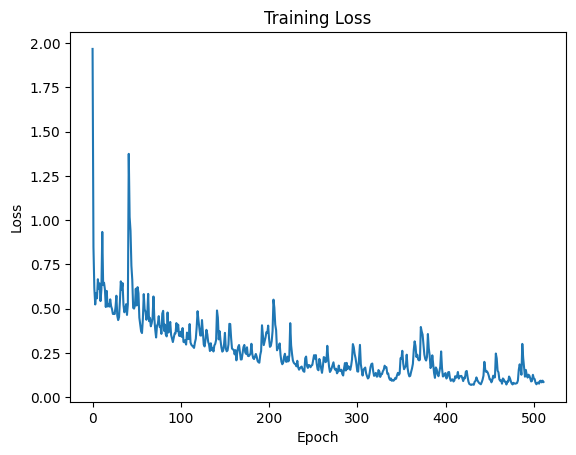

In [22]:
# Visualize learning (training loss)
import seaborn as sns
import matplotlib.pyplot as plt

# losses can come from live training or from checkpoint reload
if len(losses) == 0 and checkpoint_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    losses = [float(x) for x in checkpoint.get("losses", [])]

losses_float = [float(l) for l in losses]
loss_indices = list(range(len(losses_float)))

ax = sns.lineplot(x=loss_indices, y=losses_float)
ax.set_title("Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
plt.show()

### Visualizando as predições

In [23]:
import pandas as pd

# Analyze the results for one batch
test_batch = next(iter(test_loader))
with torch.no_grad():
    test_batch.to(device)
    pred, embed = model(test_batch.x.float(), test_batch.edge_index, test_batch.batch)
    df = pd.DataFrame()
    df["y_real"] = test_batch.y.tolist()
    df["y_pred"] = pred.tolist()
df["y_real"] = df["y_real"].apply(lambda row: row[0])
df["y_pred"] = df["y_pred"].apply(lambda row: row[0])
df

,y_real,y_pred
0,-4.360,-5.495062
1,-3.180,-2.874361
2,-5.115,-7.085861
3,-8.560,-7.626225
4,-3.840,-5.351659
...,...,...
59,-8.400,-8.130089
60,-3.630,-4.506669
61,-2.050,-2.112769
62,-2.593,-2.377693


<Axes: xlabel='y_real', ylabel='y_pred'>

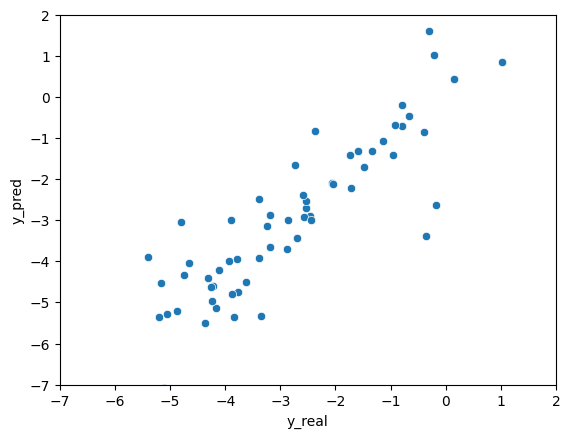

In [24]:
plt = sns.scatterplot(data=df, x="y_real", y="y_pred")
plt.set(xlim=(-7, 2))
plt.set(ylim=(-7, 2))
plt

## Melhorando o modelo / Mais coisas para experimentar

 
Por exemplo, você pode adicionar:
- Dropouts (Conforme as técnicas de regularização do curso)
- Outras camadas de Pooling (mais inteligentes) (todas as camadas disponíveis aqui: https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#)
- Camadas de Global Pooling
- Batch Normalization (Normalização de Lote)
- Mais camadas de MP (Message Passing)
- Outros tamanhos de estado oculto (hidden state sizes)
- Métricas de Teste (erro de teste) e Otimização de Hiperparâmetros
- ...

https://github.com/rusty1s/pytorch_geometric/tree/master/examples